In [1]:
##  Data Loading
import pandas as pd
features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

print(features.head())
print(price.head())

print(features.columns)
print(price.columns)

   hotel_id       city  distance  stars  rating      country city_actual  \
0         1  Amsterdam       3.1    4.0     4.3  Netherlands   Amsterdam   
1         2  Amsterdam       0.9    2.0     4.1  Netherlands   Amsterdam   
2         3  Amsterdam       1.5    4.0     4.1  Netherlands   Amsterdam   
3         4  Amsterdam       1.9    3.0     3.5  Netherlands   Amsterdam   
4         5  Amsterdam       1.8    3.5     4.0  Netherlands   Amsterdam   

   rating_reviewcount center1label      center2label neighbourhood  ratingta  \
0              1030.0  City centre  Montelbaanstoren     Amsterdam       4.0   
1               372.0  City centre  Montelbaanstoren     Amsterdam       4.0   
2               165.0  City centre  Montelbaanstoren     Amsterdam       4.0   
3               298.0  City centre  Montelbaanstoren     Amsterdam       3.5   
4                 4.0  City centre  Montelbaanstoren     Amsterdam       4.5   

   ratingta_count  distance_alter accommodation_type  
0      

In [2]:
df = pd.merge(features, price, on="hotel_id")

print(df.shape)
print(df.head())

(148021, 24)
   hotel_id       city  distance  stars  rating      country city_actual  \
0         1  Amsterdam       3.1    4.0     4.3  Netherlands   Amsterdam   
1         1  Amsterdam       3.1    4.0     4.3  Netherlands   Amsterdam   
2         1  Amsterdam       3.1    4.0     4.3  Netherlands   Amsterdam   
3         1  Amsterdam       3.1    4.0     4.3  Netherlands   Amsterdam   
4         1  Amsterdam       3.1    4.0     4.3  Netherlands   Amsterdam   

   rating_reviewcount center1label      center2label  ... accommodation_type  \
0              1030.0  City centre  Montelbaanstoren  ...              Hotel   
1              1030.0  City centre  Montelbaanstoren  ...              Hotel   
2              1030.0  City centre  Montelbaanstoren  ...              Hotel   
3              1030.0  City centre  Montelbaanstoren  ...              Hotel   
4              1030.0  City centre  Montelbaanstoren  ...              Hotel   

   price  offer     offer_cat  year  month  weeke

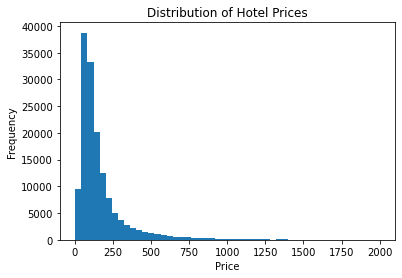

In [3]:
import matplotlib.pyplot as plt
df = df[df["price"] < 2000]
plt.hist(df["price"], bins=50)

plt.title("Distribution of Hotel Prices")

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [4]:
## Data Preprocessing
df = df.drop(columns=[
    "hotel_id",
    "country",
    "city_actual",
    "center1label",
    "center2label",
    "neighbourhood"
])
df = pd.get_dummies(df, columns=[
    "city",
    "accommodation_type",
    "offer_cat"
])
X = df.drop(columns=["price"])
y = df["price"]

In [22]:
## Train-Test Split
df = df[df["price"] < 2000]

df = df.dropna()

df = pd.get_dummies(df)

X = df.drop(columns=["price"])
y = df["price"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse_lr)

RMSE: 111.41257656999971


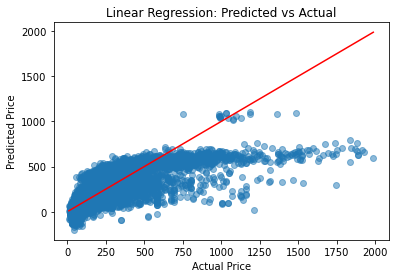

In [6]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Predicted vs Actual")

plt.show()

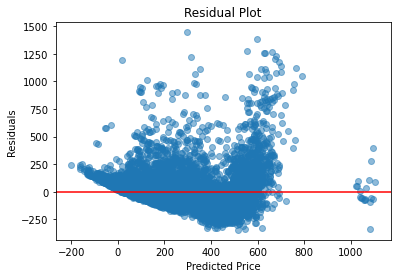

In [7]:
residuals = y_test - pred

plt.scatter(pred, residuals, alpha=0.5)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.axhline(0, color="red")

plt.show()

In [9]:
# MLP Model
# MLP without scaling
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred_mlp))

print("MLP RMSE:", rmse)

MLP RMSE: 88.75206537971282


In [19]:
# MLP with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp = MLPRegressor(
    hidden_layer_sizes=(64,32),
    max_iter=200,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

pred_mlp = mlp.predict(X_test_scaled)

rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))

print("MLP RMSE:", rmse_mlp)

MLP RMSE: 78.00367898199914


D:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


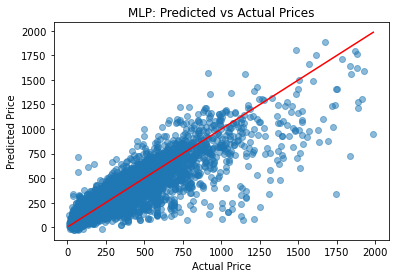

In [11]:
import matplotlib.pyplot as plt

plt.figure()

# scatter plot
plt.scatter(y_test, pred_mlp, alpha=0.5)

# baseline (perfect prediction line)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("MLP: Predicted vs Actual Prices")

plt.show()

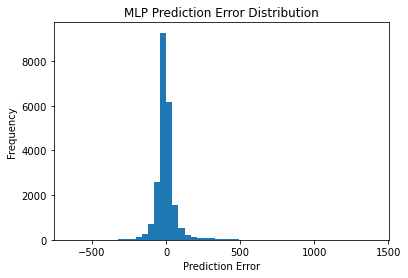

In [12]:
errors = y_test - pred_mlp

plt.figure()

plt.hist(errors, bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("MLP Prediction Error Distribution")

plt.show()

In [13]:
#LSTM Model
import pandas as pd
import numpy as np

features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

df_seq = pd.merge(features, price, on="hotel_id")
df_seq = df_seq.sort_values(["hotel_id", "year", "month"])
lstm_df = df_seq[["hotel_id", "year", "month", "price"]]


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

lstm_df["price_scaled"] = scaler.fit_transform(lstm_df[["price"]])

sequence_length = 6

X_seq = []
y_seq = []

for hotel_id, group in lstm_df.groupby("hotel_id"):

    prices = group["price_scaled"].values

    for i in range(len(prices) - sequence_length):

        X_seq.append(prices[i:i+sequence_length])
        y_seq.append(prices[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)



from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)



from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(64, input_shape=(sequence_length, 1)))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)


model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)



pred_lstm = model.predict(X_test_seq)



pred_real = scaler.inverse_transform(pred_lstm)

y_test_real = scaler.inverse_transform(y_test_seq.reshape(-1,1))



from sklearn.metrics import mean_squared_error

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_real))

print("LSTM RMSE:", rmse_lstm)

C:\Users\47193\AppData\Local\Temp/ipykernel_13656/2220177377.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lstm_df["price_scaled"] = scaler.fit_transform(lstm_df[["price"]])


X_seq shape: (39881, 6, 1)
y_seq shape: (39881,)
Epoch 1/30


D:\ProgramData\Anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


898/898 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 6.2629e-06 - val_loss: 4.4316e-06
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.4700e-06 - val_loss: 4.4353e-06
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.4661e-06 - val_loss: 3.6336e-06
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.7932e-06 - val_loss: 3.2621e-06
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.7656e-06 - val_loss: 3.9470e-06
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.2394e-06 - val_loss: 3.6624e-06
Epoch 7/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.0572e-06 - val_loss: 3.5876e-06
Epoch 8/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.7259e-06 - val_loss: 3.3735e-06
Epoch 9/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.1364e-06 - val_loss: 3.4127e-06
Epoch 10/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.7449e-06 - val_loss: 3.6900e-06
Epoch 11/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.0276e-0

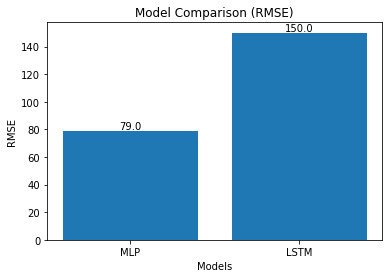

In [14]:
import matplotlib.pyplot as plt

model_names = ["MLP", "LSTM"]
rmse_values = [79, 150]

plt.figure()

bars = plt.bar(model_names, rmse_values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}",
             ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("RMSE")

plt.title("Model Comparison (RMSE)")

plt.show()

               Model        RMSE
0  Linear Regression  111.412577
1                MLP   78.003679
2               LSTM   75.051979


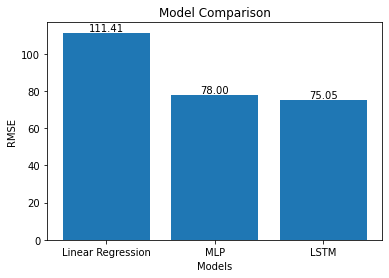

In [21]:
# Model Comparison
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "MLP", "LSTM"],
    "RMSE": [rmse_lr, rmse_mlp, rmse_lstm]
})

print(results_df)

plt.figure()
bars = plt.bar(results_df["Model"], results_df["RMSE"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
             ha="center", va="bottom")

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison")
plt.show()

In [23]:
# Visual Representation Model
import numpy as np
from sklearn.preprocessing import MinMaxScaler

X_tab = X.copy()

visual_scaler = MinMaxScaler()
X_tab_scaled = visual_scaler.fit_transform(X_tab)

def tabular_to_image_features(X_array, image_size=(8, 8)):
    n_samples, n_features = X_array.shape
    target_size = image_size[0] * image_size[1]
    
    image_features = []
    
    for row in X_array:
        if len(row) < target_size:
            padded = np.pad(row, (0, target_size - len(row)), mode='constant')
        else:
            padded = row[:target_size]
        
        img = padded.reshape(image_size)
        
        image_features.append(img.flatten())
    
    return np.array(image_features)

X_visual = tabular_to_image_features(X_tab_scaled, image_size=(8, 8))

print("Visual feature shape:", X_visual.shape)

Visual feature shape: (110146, 64)


In [24]:
from sklearn.model_selection import train_test_split

X_train_visual, X_test_visual, y_train_visual, y_test_visual = train_test_split(
    X_visual,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train_visual.shape, X_test_visual.shape)

(88116, 64) (22030, 64)


In [26]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

visual_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=200,
    early_stopping=True,
    random_state=42
)

visual_model.fit(X_train_visual, y_train_visual)

pred_visual = visual_model.predict(X_test_visual)

rmse_visual = np.sqrt(mean_squared_error(y_test_visual, pred_visual))

print("Visual Model RMSE:", rmse_visual)

Visual Model RMSE: 81.3010643918665


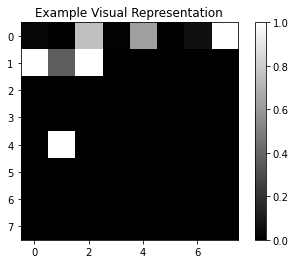

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(X_train_visual[0].reshape(8, 8), cmap="gray")
plt.title("Example Visual Representation")
plt.colorbar()
plt.show()

In [28]:
# Multimodal Model
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(np.all(y_train_tab.values == y_train_visual.values))
print(np.all(y_test_tab.values == y_test_visual.values))

X_train_multi = np.concatenate([X_train_tab, X_train_visual], axis=1)
X_test_multi = np.concatenate([X_test_tab, X_test_visual], axis=1)

print("Multimodal train shape:", X_train_multi.shape)
print("Multimodal test shape:", X_test_multi.shape)

True
True
Multimodal train shape: (88116, 151)
Multimodal test shape: (22030, 151)


In [29]:
multi_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    early_stopping=True,
    random_state=42
)

multi_model.fit(X_train_multi, y_train_tab)

pred_multi = multi_model.predict(X_test_multi)

rmse_multi = np.sqrt(mean_squared_error(y_test_tab, pred_multi))

print("Multimodal Model RMSE:", rmse_multi)

Multimodal Model RMSE: 78.87238378538366


In [32]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "MLP",
        "LSTM",
        "Visual",
        "Multimodal"
    ],
    "RMSE": [
        rmse_lr,
        rmse_mlp,
        rmse_lstm,
        rmse_visual,
        rmse_multi
    ]
})

print(results_df)

               Model        RMSE
0  Linear Regression  111.412577
1                MLP   78.003679
2               LSTM   75.051979
3             Visual   81.301064
4         Multimodal   78.872384


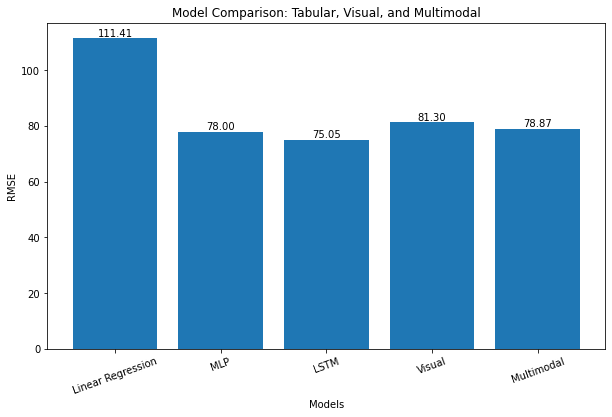

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df["Model"], results_df["RMSE"])

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison: Tabular, Visual, and Multimodal")
plt.xticks(rotation=20)
plt.show()

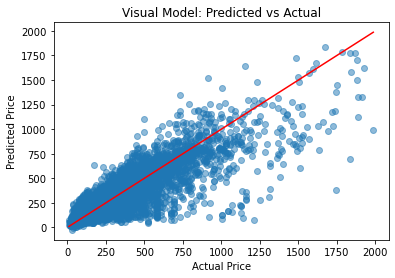

In [34]:
plt.figure()
plt.scatter(y_test_visual, pred_visual, alpha=0.5)

plt.plot(
    [y_test_visual.min(), y_test_visual.max()],
    [y_test_visual.min(), y_test_visual.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Visual Model: Predicted vs Actual")
plt.show()

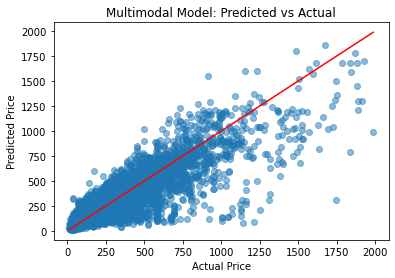

In [31]:
plt.figure()
plt.scatter(y_test_tab, pred_multi, alpha=0.5)

plt.plot(
    [y_test_tab.min(), y_test_tab.max()],
    [y_test_tab.min(), y_test_tab.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multimodal Model: Predicted vs Actual")
plt.show()